In [2]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from env_pred import SupervisedESN
import itertools
import random


In [3]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 1) 
        if len(parts) < 2: continue
        
        terrain, sensor = parts[0], parts[1]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [4]:
import numpy as np

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set



In [5]:
def format_for_esn(dataset_dict, terrain_to_id_map, sensor_order):
    """
    Converts the nested dictionary into flat X and y lists for the ESN.
    
    dataset_dict: The output from your split_gait_dataset function.
    terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
    sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
    """
    X_formatted = []
    y_formatted = []
    
    for terrain, sensors_data in dataset_dict.items():
        if terrain not in terrain_to_id_map:
            continue # Skip terrains we aren't training on
            
        label = terrain_to_id_map[terrain]
        
        # Get the number of cycles for this terrain (they are synchronized)
        n_cycles = len(sensors_data[sensor_order[0]])
        
        for i in range(n_cycles):
            # For cycle 'i', gather data from all 16 joints (K, D, tau)
            cycle_columns = []
            for sensor_name in sensor_order:
                # Ensure it's a numpy array
                sensor_array = np.array(sensors_data[sensor_name][i])
                
                # If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
                if len(sensor_array.shape) == 1:
                    sensor_array = sensor_array.reshape(-1, 1)
                    
                cycle_columns.append(sensor_array)
            
            # Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
            full_gait_matrix = np.hstack(cycle_columns)
            
            X_formatted.append(full_gait_matrix)
            y_formatted.append(label)
            
    return X_formatted, np.array(y_formatted)

In [ ]:
TERRAIN_LABELS = {
    'flat': 0,
    'muddy': 1,
    'water': 2
}

model_list = ["env_pred_esn_best_joint_kdf",
              "env_pred_esn_best_leg_kdf",
              "env_pred_esn_best_joint_tor",
              "env_pred_esn_best_leg_grf",
              "env_pred_esn_best_joint_tor_grf"]
sensor_list = [['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
              ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
              ['joint_torque_fb'],
              ['foot_force'],
              ['joint_torque_fb', 'foot_force']]

# SENSOR_KEYS = list(dataset['flat'].keys()) 


print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

accuracy_dict = {}

for sensor_key, model_file in zip(sensor_list, model_list):
    print("\nFormatting data for ESN...")

    X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, sensor_key)
    X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, sensor_key)

    # print(f"Total Training Cycles: {len(X_train)}")
    # print(f"Total Testing Cycles: {len(X_test)}")
    # print(f"Input Matrix Shape: {X_train[0].shape}") # Should be (timesteps_of_cycle, features x sensors)

    print("Booting up ESN Controller...")

    model = SupervisedESN()
    model.load_model(f"{model_file}.npz")


    print("\nEvaluating on unseen Test Set...")
    y_pred = []

    # Collect all predictions
    for i in range(len(X_test)):
        predicted_class, confidence = model.predict(X_test[i])
        y_pred.append(predicted_class)

    # Convert to numpy array for fast comparison
    y_pred = np.array(y_pred)

    # Calculate Accuracy
    correct = np.sum(y_pred == y_test)
    accuracy = (correct / len(X_test)) * 100
    print(f"Test Accuracy: {accuracy:.2f}%")

    accuracy_dict[model_file] = accuracy

Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)

Formatting data for ESN...
Booting up ESN Controller...

[SUCCESS] ESN Model loaded from: 'env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------


Evaluating on unseen Test Set...
Test Accuracy: 94.32%

Formatting data for ESN...
Booting up ESN Controller...

[SUCCESS] ESN Model loaded from: 'env_pred_esn_best_leg_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 500 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix 

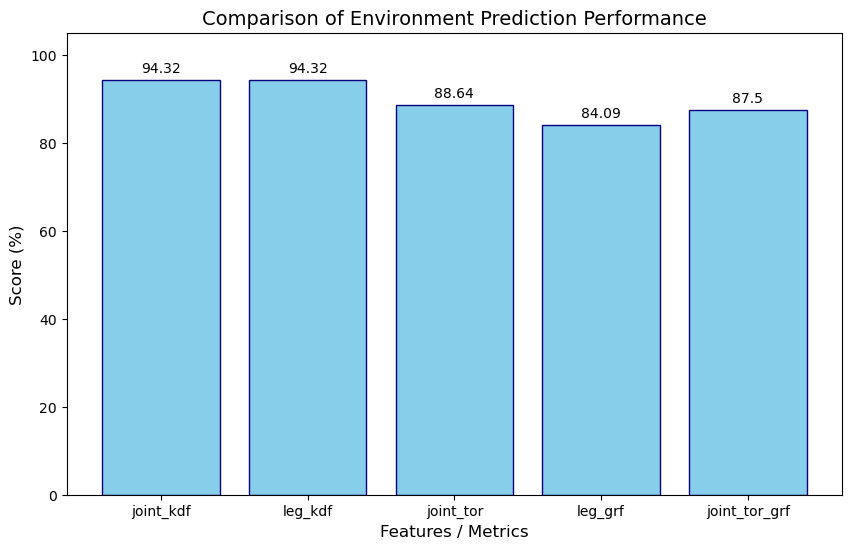

In [18]:
labels = [key.replace("env_pred_esn_best_", "") for key in accuracy_dict.keys()]
values = list(accuracy_dict.values())

plt.figure(figsize=(10, 6))

bars = plt.bar(labels, values, color='skyblue', edgecolor='navy')

plt.title('Comparison of Environment Prediction Performance', fontsize=14)
plt.xlabel('Features / Metrics', fontsize=12)
plt.ylabel('Score (%)', fontsize=12)
plt.ylim(0, 105) 

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom')
